In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load the prepared dataset we saved yesterday
df = pd.read_csv('../data/entebbe_prepared.csv', index_col='timestamp', parse_dates=True)

print(f"Dataset loaded. Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nLabel distribution:")
print(df['status'].value_counts())

Dataset loaded. Shape: (15130, 14)

Columns: ['temperature', 'dew_point', 'wind_direction', 'wind_speed', 'time_diff', 'status', 'temperature_mean_3h', 'temperature_trend_3h', 'dew_point_mean_3h', 'dew_point_trend_3h', 'wind_speed_mean_3h', 'wind_speed_trend_3h', 'hour_of_day', 'hours_since_last']

Label distribution:
status
healthy    14587
at_risk      543
Name: count, dtype: int64


In [3]:
# Define which columns are features and which is the target
feature_cols = [
    'temperature', 'dew_point', 'wind_speed', 'wind_direction',
    'temperature_mean_3h', 'temperature_trend_3h',
    'dew_point_mean_3h', 'dew_point_trend_3h',
    'wind_speed_mean_3h', 'wind_speed_trend_3h',
    'hour_of_day'
]

target_col = 'status'

# Drop rows where any feature is missing
df_clean = df[feature_cols + [target_col]].dropna()

print(f"Shape before dropping NaN: {df.shape}")
print(f"Shape after dropping NaN:  {df_clean.shape}")
print(f"Rows dropped: {len(df) - len(df_clean)}")

# Separate features (X) and target (y)
X = df_clean[feature_cols]
y = df_clean[target_col]

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nLabel distribution after cleaning:")
print(y.value_counts())

Shape before dropping NaN: (15130, 14)
Shape after dropping NaN:  (13958, 12)
Rows dropped: 1172

X shape: (13958, 11)
y shape: (13958,)

Label distribution after cleaning:
status
healthy    13461
at_risk      497
Name: count, dtype: int64


In [4]:
# Split into training set and test set
# 80% for training, 20% for testing
# The model will NEVER see the test set during training
# We use it only to evaluate how well it generalised

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,        # makes the split reproducible — same split every run
    stratify=y              # ensures both splits have the same at_risk ratio
)

print(f"Training set:  {X_train.shape[0]} rows")
print(f"Test set:      {X_test.shape[0]} rows")
print(f"\nTraining label distribution:")
print(y_train.value_counts())
print(f"\nTest label distribution:")
print(y_test.value_counts())

Training set:  11166 rows
Test set:      2792 rows

Training label distribution:
status
healthy    10768
at_risk      398
Name: count, dtype: int64

Test label distribution:
status
healthy    2693
at_risk      99
Name: count, dtype: int64


In [5]:
# Train the Random Forest classifier
model = RandomForestClassifier(
    n_estimators=100,      # number of trees
    max_depth=10,          # how deep each tree can grow
    class_weight='balanced', # compensates for the imbalance (97% healthy, 3% at_risk)
    random_state=42,
    n_jobs=-1              # use all CPU cores to train faster
)

print("Training model...")
model.fit(X_train, y_train)
print("Done.")

# Quick check — score on training data
train_score = model.score(X_train, y_train)
print(f"\nTraining accuracy: {train_score:.4f}")

Training model...
Done.

Training accuracy: 0.8926


In [6]:
# Evaluate on the test set
y_pred = model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

     at_risk       0.06      0.22      0.10        99
     healthy       0.97      0.87      0.92      2693

    accuracy                           0.85      2792
   macro avg       0.51      0.55      0.51      2792
weighted avg       0.94      0.85      0.89      2792



In [7]:
# Get probability scores instead of hard predictions
y_proba = model.predict_proba(X_test)

# predict_proba returns two columns: [prob_healthy, prob_at_risk]
# Check which column is which
print("Classes:", model.classes_)
print("Sample probabilities (first 5 rows):")
print(y_proba[:5])

Classes: ['at_risk' 'healthy']
Sample probabilities (first 5 rows):
[[0.40858922 0.59141078]
 [0.43172683 0.56827317]
 [0.23680433 0.76319567]
 [0.15344455 0.84655545]
 [0.34019401 0.65980599]]


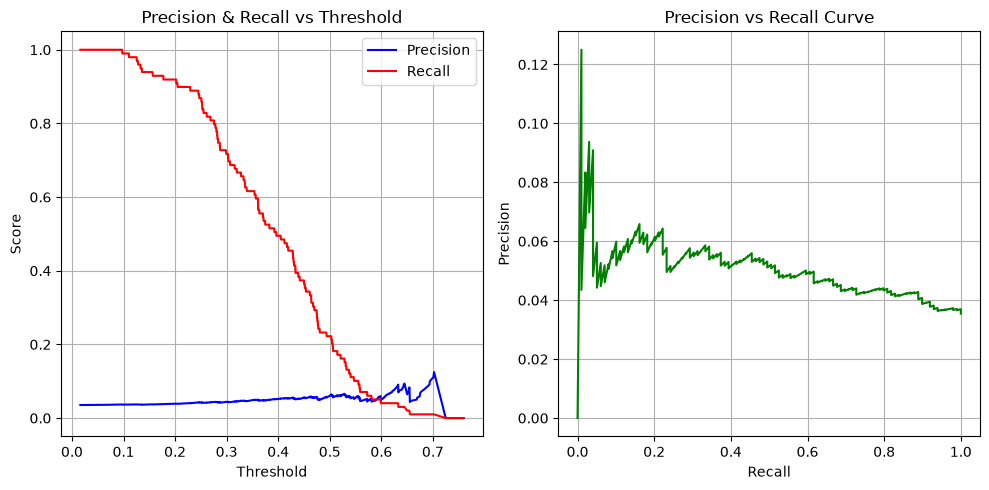

Best threshold for recall >= 0.5: 0.396


In [8]:
from sklearn.metrics import precision_recall_curve
import numpy as np

# Extract just the at_risk probability column
at_risk_proba = y_proba[:, 0]

# Calculate precision and recall at every possible threshold
precisions, recalls, thresholds = precision_recall_curve(
    y_test, 
    at_risk_proba, 
    pos_label='at_risk'
)

# Plot precision vs recall at different thresholds
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(thresholds, precisions[:-1], label='Precision', color='blue')
plt.plot(thresholds, recalls[:-1], label='Recall', color='red')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision & Recall vs Threshold')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(recalls[:-1], precisions[:-1], color='green')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision vs Recall Curve')
plt.grid(True)

plt.tight_layout()
plt.savefig('../data/precision_recall_curve.png', dpi=150)
plt.show()

# Find threshold where recall for at_risk is at least 0.5
good_thresholds = thresholds[recalls[:-1] >= 0.5]
if len(good_thresholds) > 0:
    best_threshold = good_thresholds[-1]
    print(f"Best threshold for recall >= 0.5: {best_threshold:.3f}")
else:
    print("No threshold achieves recall >= 0.5")

Results at threshold 0.396:
              precision    recall  f1-score   support

     at_risk       0.05      0.51      0.09        99
     healthy       0.97      0.66      0.79      2693

    accuracy                           0.66      2792
   macro avg       0.51      0.58      0.44      2792
weighted avg       0.94      0.66      0.76      2792



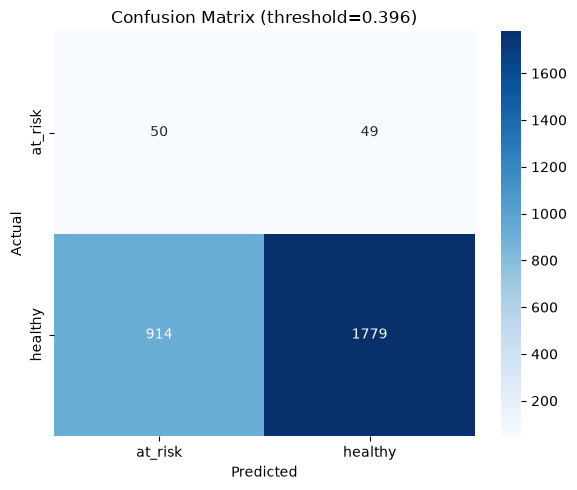

In [9]:
# Apply the best threshold
best_threshold = 0.396
y_pred_tuned = np.where(at_risk_proba >= best_threshold, 'at_risk', 'healthy')

print(f"Results at threshold {best_threshold}:")
print(classification_report(y_test, y_pred_tuned))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_tuned, labels=['at_risk', 'healthy'])
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d',
    xticklabels=['at_risk', 'healthy'],
    yticklabels=['at_risk', 'healthy'],
    cmap='Blues'
)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title(f'Confusion Matrix (threshold={best_threshold})')
plt.tight_layout()
plt.savefig('../data/confusion_matrix.png', dpi=150)
plt.show()

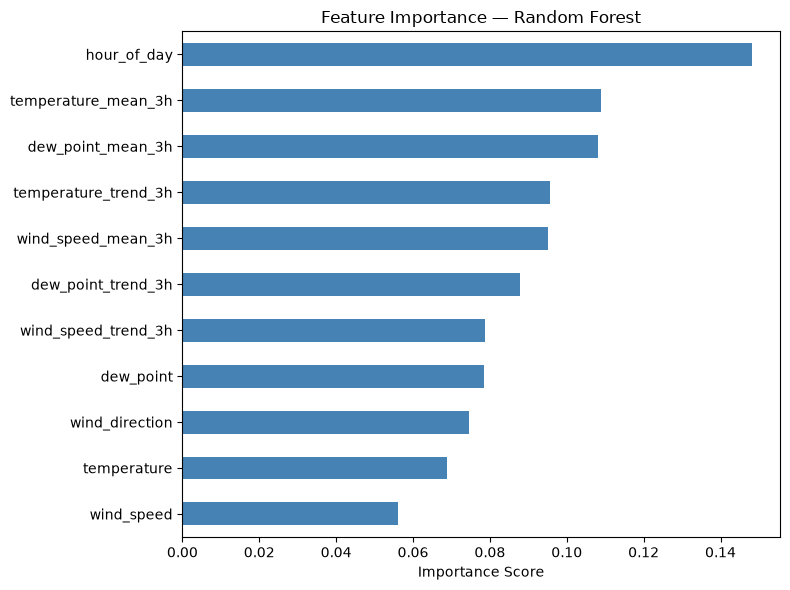


Feature importance ranking:
hour_of_day             0.1481
temperature_mean_3h     0.1088
dew_point_mean_3h       0.1081
temperature_trend_3h    0.0955
wind_speed_mean_3h      0.0952
dew_point_trend_3h      0.0877
wind_speed_trend_3h     0.0787
dew_point               0.0784
wind_direction          0.0746
temperature             0.0689
wind_speed              0.0561
dtype: float64


In [10]:
# Feature importance — which features did the model rely on most?
importances = pd.Series(
    model.feature_importances_,
    index=feature_cols
).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
importances.plot(kind='barh', color='steelblue')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../data/feature_importance.png', dpi=150)
plt.show()

print("\nFeature importance ranking:")
print(importances.sort_values(ascending=False).round(4))

In [11]:
import joblib
import os

# Create models directory
os.makedirs('../models', exist_ok=True)

# Save the trained model
joblib.dump(model, '../models/station_health_model.pkl')

# Save the threshold we found
joblib.dump(best_threshold, '../models/classification_threshold.pkl')

# Save the feature column names — critical for when we load the model later
joblib.dump(feature_cols, '../models/feature_cols.pkl')

print("Saved:")
print("  ../models/station_health_model.pkl")
print("  ../models/classification_threshold.pkl")
print("  ../models/feature_cols.pkl")

# Verify by loading back
model_loaded    = joblib.load('../models/station_health_model.pkl')
threshold_loaded = joblib.load('../models/classification_threshold.pkl')
features_loaded  = joblib.load('../models/feature_cols.pkl')

print(f"\nVerification:")
print(f"  Model loaded: {type(model_loaded)}")
print(f"  Threshold: {threshold_loaded}")
print(f"  Features: {features_loaded}")

Saved:
  ../models/station_health_model.pkl
  ../models/classification_threshold.pkl
  ../models/feature_cols.pkl

Verification:
  Model loaded: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
  Threshold: 0.396
  Features: ['temperature', 'dew_point', 'wind_speed', 'wind_direction', 'temperature_mean_3h', 'temperature_trend_3h', 'dew_point_mean_3h', 'dew_point_trend_3h', 'wind_speed_mean_3h', 'wind_speed_trend_3h', 'hour_of_day']
